#  Fine-Tuning DistilBERT for Emotion Classification
**Dataset:** `dair-ai/emotion`   
**Model:** `distilbert-base-uncased`  

## 1. Install Dependencies

In [16]:
!pip install -q transformers datasets evaluate accelerate scikit-learn seaborn

## 2. Imports

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import evaluate
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device      : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU device      : Tesla T4


## 3. Load the Dataset

In [18]:
#get the complet dataset the unsplitting one
full_dataset = load_dataset("dair-ai/emotion", "unsplit")
print(full_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 416809
    })
})


## 4. Explore the Data

In [19]:
# Label names
label_names = full_dataset["train"].features["label"].names
print("Labels:", label_names)


Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [20]:
# few examples
df_raw = full_dataset["train"].to_pandas()
df_raw["label_name"] = df_raw["label"].map(lambda x: label_names[x])
df_raw.head(10)

,text,label,label_name
0,i feel awful about it too because it s my job ...,0,sadness
1,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i reall...,1,joy
3,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to oth...,2,love
5,i find myself frustrated with christians becau...,2,love
6,i am one of those people who feels like going ...,1,joy
7,i feel especially pleased about this as this h...,1,joy
8,i was struggling with these awful feelings and...,1,joy
9,i feel so enraged but helpless at the same time,3,anger


In [21]:
# Show 3 random examples per emotion
print("=== Sample Texts per Emotion ===")
for emotion in label_names:
    samples = df_raw[df_raw["label_name"] == emotion]["text"].sample(3, random_state=42).tolist()
    print(f"\n[{emotion.upper()}]")
    for s in samples:
        print(f"  • {s}")

=== Sample Texts per Emotion ===

[SADNESS]
  • i feel sorry about you because your point of view is indoctrinated by these left wing european historical revisionists textbooks
  • i feel like he s watching quietly because he s resigned he s come to realize that people are going to die and there s nothing he can do about it
  • i feel im ugly ugly ugly and ugly now

[JOY]
  • i feel pretty talented
  • i mean not much to feel obviously we have to look after ourselves and as i said i m very happy
  • i feel excited and honored to have been given this opportunity by pulkit and ila

[LOVE]
  • i swore i could feel the cherishment in every gentle stroke
  • i feel so devoted to my relationship and to myself which luckily go hand in hand for me
  • i feel that if it was an image of someone doing something that they didnt want others to see such as the work of paul graham beyond caring i can see a reason why you would want something in return as these people are vunerable and run down while 

In [22]:
# Text length distribution
df_raw["text_len"] = df_raw["text"].str.split().str.len()
print(df_raw["text_len"].describe())

count    416809.000000
mean         19.211015
std          11.051049
min           1.000000
25%          11.000000
50%          17.000000
75%          25.000000
max         178.000000
Name: text_len, dtype: float64


## 5. Visualize Label Distribution

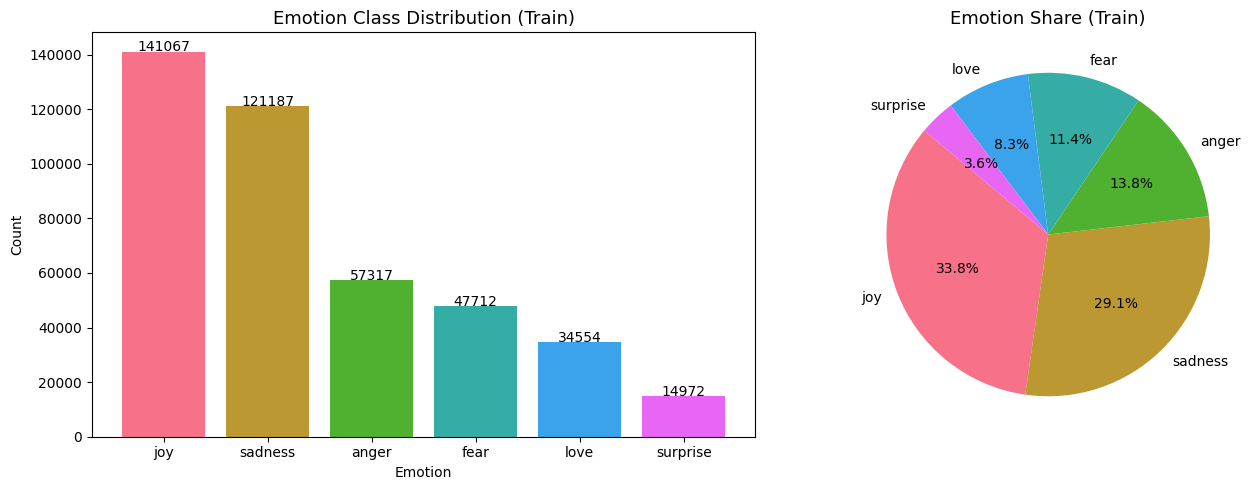

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: class counts ---
counts = df_raw["label_name"].value_counts()
colors = sns.color_palette("husl", len(label_names))
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Emotion Class Distribution (Train)", fontsize=13)
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=10)

# --- Pie chart ---
axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
)
axes[1].set_title("Emotion Share (Train)", fontsize=13)

plt.tight_layout()
plt.savefig("emotion_distribution.png", dpi=120)
plt.show()

---------------

In [24]:
# undersampling the data 
min_class_size = df_raw['label'].value_counts().min()
print(f"Balancing all classes to {min_class_size} rows")

Balancing all classes to 14972 rows


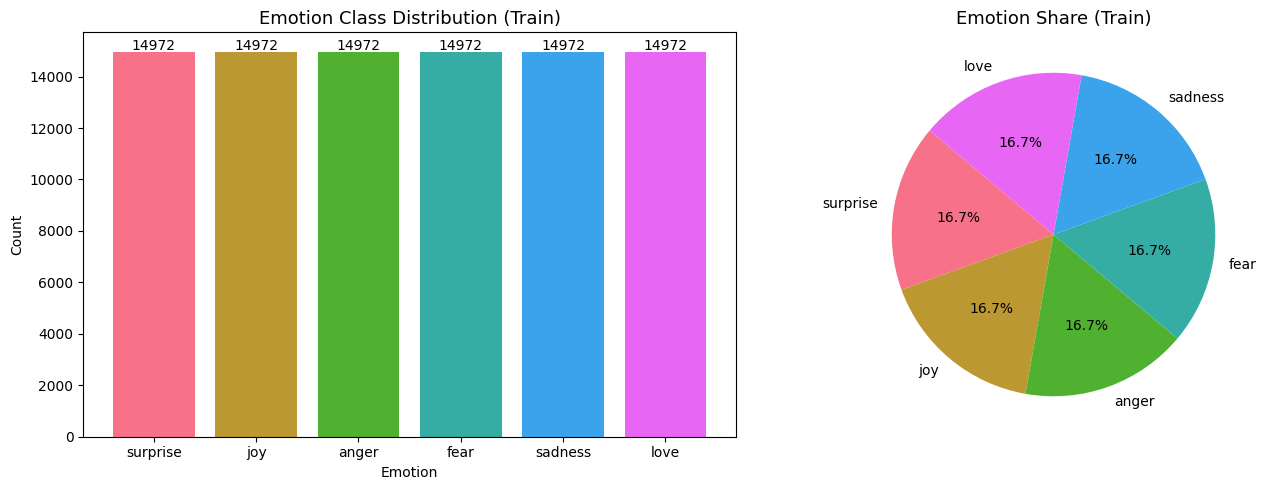

In [31]:
df_balanced = df_raw.groupby('label').sample(n=min_class_size, random_state=42)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# verify the new distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: class counts ---
counts = df_balanced["label_name"].value_counts()
colors = sns.color_palette("husl", len(label_names))
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Emotion Class Distribution (Train)", fontsize=13)
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=10)


axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
)
axes[1].set_title("Emotion Share (Train)", fontsize=13)

plt.tight_layout()
plt.savefig("emotion_distribution.png", dpi=120)
plt.show()

In [26]:
# Convert back to a Hugging Face Dataset
balanced_dataset = Dataset.from_pandas(df_balanced)


# divide the data to train, test and validation
train_temp = balanced_dataset.train_test_split(test_size=0.2, seed=42)
test_valid = train_temp['test'].train_test_split(test_size=0.5, seed=42)


balanced_splits = DatasetDict(
    {
        "train": train_temp['train'],
        "validation": test_valid['train'],
        "test": test_valid['test']
    }
)


print('the final dataset:')
print(balanced_splits)

the final dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'text_len'],
        num_rows: 71865
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'text_len'],
        num_rows: 8983
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'text_len'],
        num_rows: 8984
    })
})


## 6. Tokenize the Dataset

In [33]:
MODEL_NAME = "distilbert-base-uncased"
NUM_LABELS = len(label_names)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

# Map tokenization over the BALANCED splits
tokenized_dataset = balanced_splits.map(tokenize, batched=True)

# Format for PyTorch
tokenized_dataset = tokenized_dataset.remove_columns(["text", "label_name", "text_len"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

print(tokenized_dataset)

Map:   0%|          | 0/71865 [00:00<?, ? examples/s]

Map:   0%|          | 0/8983 [00:00<?, ? examples/s]

Map:   0%|          | 0/8984 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 71865
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8983
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8984
    })
})


## 7. Load DistilBERT Model

In [34]:
id2label = {i: label_names[i] for i in range(NUM_LABELS)}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params     : 66,958,086
Trainable params : 66,958,086


## 8. Metrics

In [35]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}

## 9. Training Arguments & Trainer

In [38]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

batch_size = 128
total_training_steps = (len(tokenized_dataset["train"]) // batch_size) * 3
calculated_warmup_steps = int(total_training_steps * 0.1)


training_args = TrainingArguments(
    output_dir="./distilbert-emotion",
    num_train_epochs=3,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=calculated_warmup_steps,  
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    fp16=True,               
    report_to="none",        
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,           
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

## 10. Train!

In [39]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.490550,0.354711,0.944673,0.944241
2,0.293014,0.263509,0.952466,0.952312
3,0.246322,0.249417,0.951909,0.951657


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=843, training_loss=0.7786301582309275, metrics={'train_runtime': 661.4121, 'train_samples_per_second': 325.962, 'train_steps_per_second': 1.275, 'total_flos': 3556971805487832.0, 'train_loss': 0.7786301582309275, 'epoch': 3.0})

## 11. Evaluate on Test Set

In [40]:
results = trainer.evaluate(tokenized_dataset["test"])
print("\n=== Test Set Results ===")
for k, v in results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



=== Test Set Results ===
  eval_loss: 0.2732
  eval_accuracy: 0.9501
  eval_f1: 0.9500
  eval_runtime: 10.1934
  eval_samples_per_second: 881.3580
  eval_steps_per_second: 3.5320
  epoch: 3.0000


## 12. Confusion Matrix

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


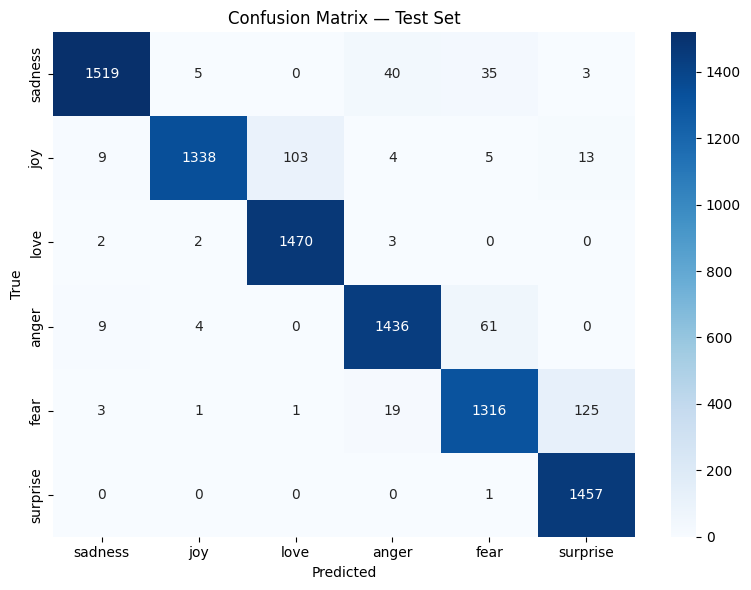


=== Classification Report ===
              precision    recall  f1-score   support

     sadness       0.99      0.95      0.97      1602
         joy       0.99      0.91      0.95      1472
        love       0.93      1.00      0.96      1477
       anger       0.96      0.95      0.95      1510
        fear       0.93      0.90      0.91      1465
    surprise       0.91      1.00      0.95      1458

    accuracy                           0.95      8984
   macro avg       0.95      0.95      0.95      8984
weighted avg       0.95      0.95      0.95      8984



In [41]:
from sklearn.metrics import confusion_matrix, classification_report

preds_output = trainer.predict(tokenized_dataset["test"])
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Confusion Matrix — Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=label_names))

## 13. Save the Model

In [42]:
model.save_pretrained("./distilbert-emotion-final")
tokenizer.save_pretrained("./distilbert-emotion-final")
print("Model saved to ./distilbert-emotion-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./distilbert-emotion-final


## 14. Quick Inference Test

In [43]:
from transformers import pipeline

clf = pipeline(
    "text-classification",
    model="./distilbert-emotion-final",
    tokenizer="./distilbert-emotion-final",
    device=0 if torch.cuda.is_available() else -1,
)

test_sentences = [
    "I am so happy today, everything is going perfectly!",
    "I feel really sad and hopeless right now.",
    "That absolutely terrified me, I'm still shaking.",
    "I'm so angry I could scream.",
    "I'm surprised this actually worked out!",
    "I feel a deep sense of disgust after hearing that news.",
]

print("=== Inference Results ===")
for sent in test_sentences:
    out = clf(sent)[0]
    print(f"Text   : {sent}")
    print(f"Pred   : {out['label']}  (score: {out['score']:.3f})")
    print()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

=== Inference Results ===
Text   : I am so happy today, everything is going perfectly!
Pred   : joy  (score: 0.952)

Text   : I feel really sad and hopeless right now.
Pred   : sadness  (score: 0.994)

Text   : That absolutely terrified me, I'm still shaking.
Pred   : fear  (score: 0.993)

Text   : I'm so angry I could scream.
Pred   : anger  (score: 0.988)

Text   : I'm surprised this actually worked out!
Pred   : surprise  (score: 0.983)

Text   : I feel a deep sense of disgust after hearing that news.
Pred   : anger  (score: 0.855)

